In [3]:
# ============================================================
# F1 2025 - Tyre Degradation Analysis
# Author: Alexandre Larde
# Data source: FastF1 (official F1 timing data)
# ============================================================

# This notebook analyses lap time evolution and tyre degradation
# across stints for the top drivers of the 2025 British Grand Prix.
# Pit stops are highlighted with dashed vertical lines.

# Key observations:
# - Lap time increase within a stint = tyre degradation
# - Drop after pit stop = fresh tyre performance gain
# - Final laps acceleration = Safety Car / track evolution

In [4]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
session_jpn = fastf1.get_session(2025, 'Japan', 'R')
session_jpn.load()
print("Chargé !")

req         WARNING 	DEFAULT CACHE ENABLED! (416.12 MB) C:\Users\alexl\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Japanese Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '44', '6', '23', '87', '14', '22', '10', '55',

Chargé !


In [14]:
import matplotlib.ticker as ticker
import numpy as np

def format_laptime(seconds, pos):
    minutes = int(seconds // 60)
    secs = seconds % 60
    return f"{minutes}:{secs:05.2f}"

laps_jpn = session_jpn.laps

drivers = {
    'VER': ('#3671C6', 'Verstappen', 'Red Bull'),
    'NOR': ('#FF8000', 'Norris', 'McLaren'),
    'PIA': ('#FF8000', 'Piastri', 'McLaren'),
    'LEC': ('#E8002D', 'Leclerc', 'Ferrari'),
    'SAI': ('#E8002D', 'Sainz', 'Ferrari'),
    'RUS': ('#27F4D2', 'Russell', 'Mercedes'),
    'HAM': ('#27F4D2', 'Hamilton', 'Mercedes'),
    'ANT': ('#27F4D2', 'Antonelli', 'Mercedes'),
    'ALO': ('#358C75', 'Alonso', 'Aston Martin'),
    'STR': ('#358C75', 'Stroll', 'Aston Martin'),
    'GAS': ('#0093CC', 'Gasly', 'Alpine'),
    'DOO': ('#0093CC', 'Doohan', 'Alpine'),
    'TSU': ('#6692FF', 'Tsunoda', 'RB'),
    'LAW': ('#6692FF', 'Lawson', 'RB'),
    'HUL': ('#C92D4B', 'Hulkenberg', 'Sauber'),
    'BOR': ('#C92D4B', 'Bortoleto', 'Sauber'),
    'ALB': ('#64C4FF', 'Albon', 'Williams'),
    'HAD': ('#64C4FF', 'Hadjar', 'Williams'),
    'OCO': ('#B6BABD', 'Ocon', 'Haas'),
    'BEA': ('#B6BABD', 'Bearman', 'Haas'),
}

# ---- PREPARATION ----
total_laps = int(laps_jpn['LapNumber'].max())
all_data = {}
for driver, (color, name, team) in drivers.items():
    data = laps_jpn[laps_jpn['Driver'] == driver].copy().dropna(subset=['LapTime'])
    if data.empty:
        continue
    data['LapTime_s'] = data['LapTime'].dt.total_seconds()
    pit_laps_in = set(data[data['PitInTime'].notna()]['LapNumber'].values)
    pit_laps_out = set(data[data['PitOutTime'].notna()]['LapNumber'].values)
    data['is_pit'] = data['LapNumber'].isin(pit_laps_in | pit_laps_out)
    data['normal'] = ~data['is_pit']
    all_data[driver] = data

def clean_stint(s):
    """Filtre les tours aberrants (safety car, incidents) via 3 sigma"""
    mean = s['LapTime_s'].mean()
    std = s['LapTime_s'].std()
    return s[np.abs(s['LapTime_s'] - mean) < 3 * std]

# ---- CALCULS ----
pace = {}
pit_losses = {}
degradation = {}
consistency = {}

for driver, (color, name, team) in drivers.items():
    if driver not in all_data:
        continue
    data = all_data[driver]
    normal = data[data['normal']]
    if len(normal) < 3:
        continue
    pace[driver] = normal['LapTime_s'].mean()

    deg_stints = {}
    con_stints = {}
    for stint in normal['Stint'].unique():
        s = normal[normal['Stint'] == stint].sort_values('LapNumber')
        s = clean_stint(s)
        if len(s) < 3:
            continue
        coef = np.polyfit(s['LapNumber'].values, s['LapTime_s'].values, 1)
        deg_stints[int(stint)] = coef[0] * 1000
        con_stints[int(stint)] = s['LapTime_s'].std()
    degradation[driver] = deg_stints
    consistency[driver] = con_stints

    pit_laps = data[data['PitInTime'].notna()]['LapNumber'].values
    for pit_lap in pit_laps:
        inlap = data[data['LapNumber'] == pit_lap]['LapTime_s'].values
        outlap = data[data['LapNumber'] == pit_lap + 1]['LapTime_s'].values
        ref = data[(data['LapNumber'] >= pit_lap - 3) &
                   (data['LapNumber'] < pit_lap) &
                   data['normal']]['LapTime_s'].values
        if len(inlap) == 0 or len(outlap) == 0 or len(ref) == 0:
            continue
        loss = (inlap[0] + outlap[0]) - 2 * ref.mean()
        # Filtrer les valeurs aberrantes (> 40s de perte = suspect)
        if loss > 40:
            continue
        pit_losses[driver] = {
            'loss': loss,
            'inlap': inlap[0] - ref.mean(),
            'outlap': outlap[0] - ref.mean()
        }


## Lap Time Evolution

This chart shows the lap time for each driver across the full race distance.
Each spike corresponds to the pit stop lap (inlap + outlap).
The dashed vertical line marks the pit stop entry lap.
Grey zones indicate laps where FastF1 data is unavailable.

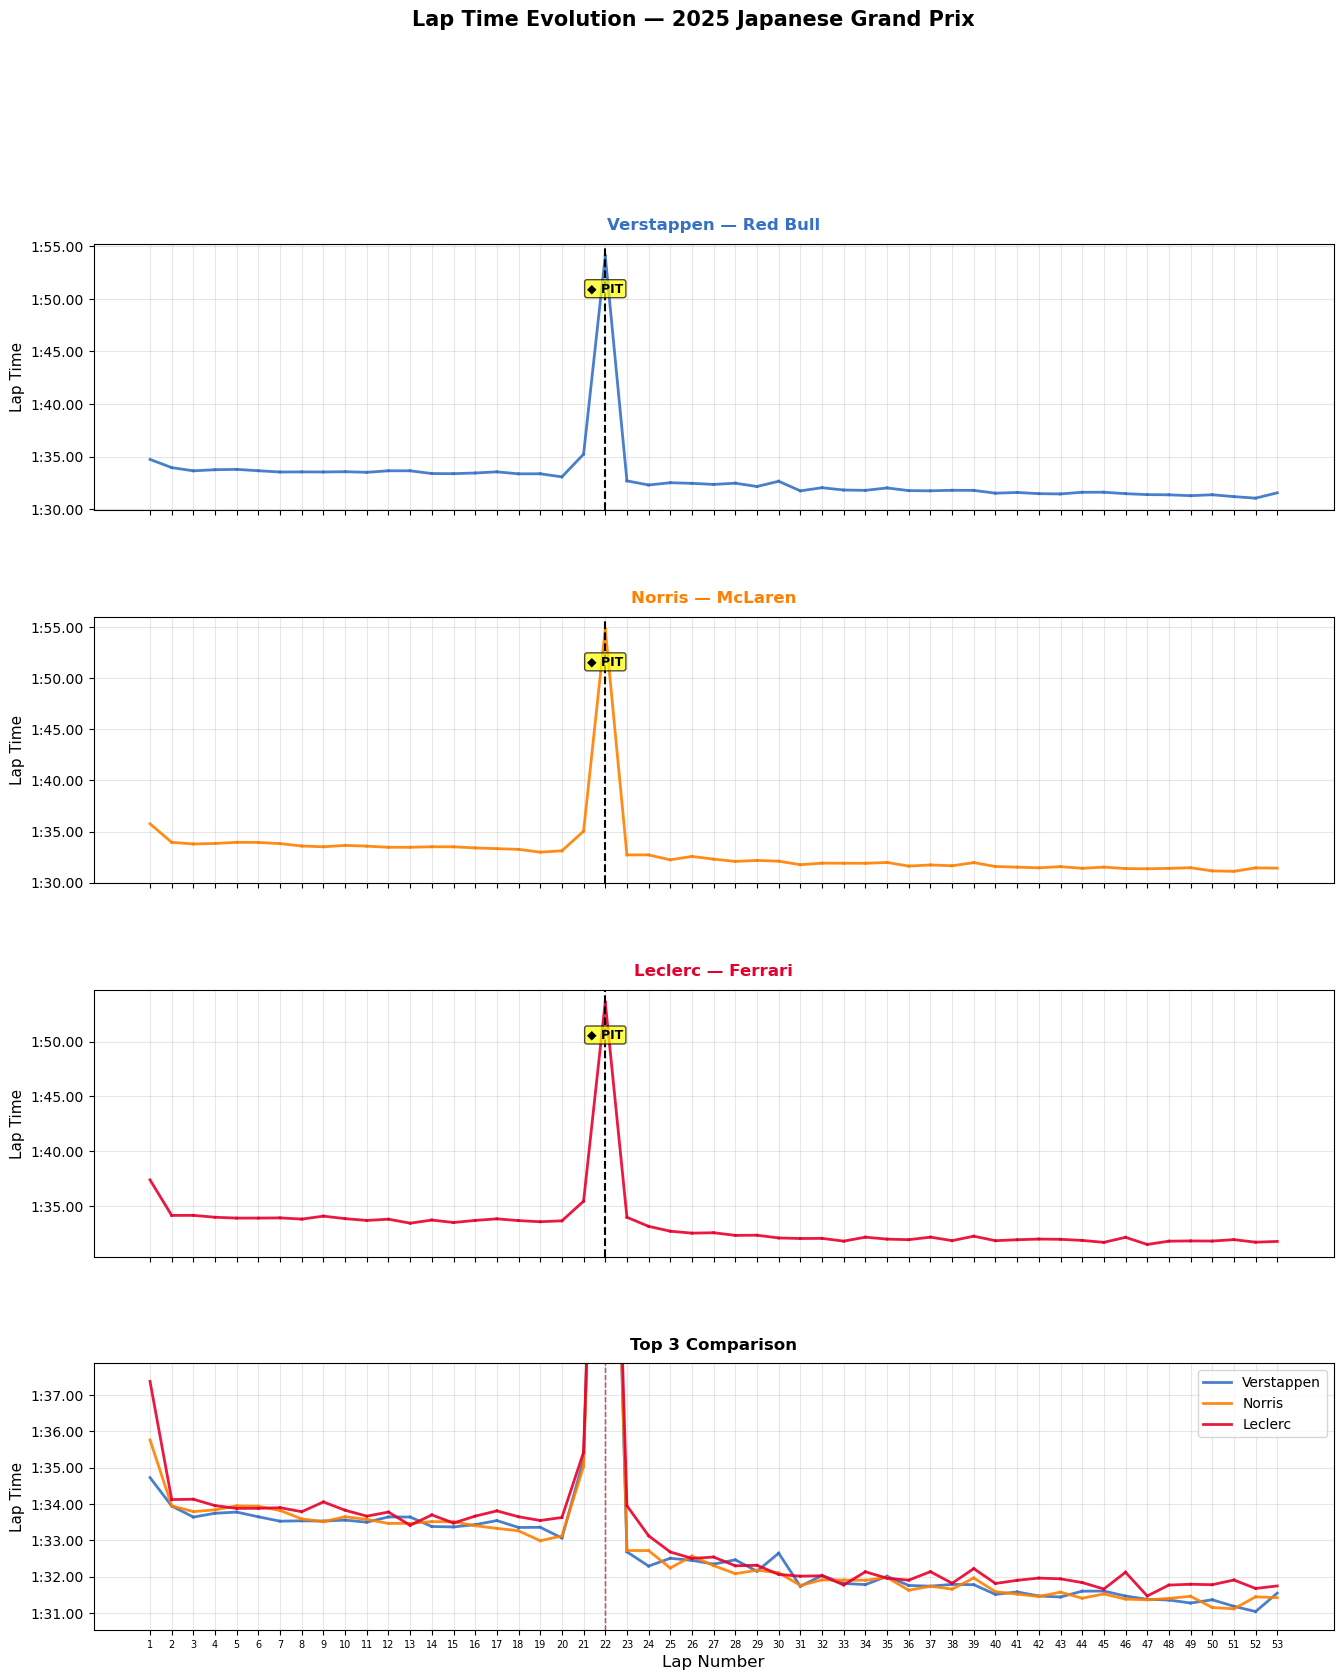

Figure 1 saved!


In [15]:
# ======================================================
# FIGURE 1 — LAP TIME EVOLUTION
# ======================================================
top3 = ['VER', 'NOR', 'LEC']
fig1, axes = plt.subplots(4, 1, figsize=(16, 18), sharex=True)
fig1.subplots_adjust(hspace=0.4)

for ax, driver in zip(axes[:3], top3):
    color, name, team = drivers[driver]
    data = all_data[driver]
    available_laps = set(data['LapNumber'].values)

    prev_lap = None
    prev_time = None
    for _, row in data.iterrows():
        curr_lap = row['LapNumber']
        curr_time = row['LapTime_s']
        if prev_lap is not None and curr_lap == prev_lap + 1:
            ax.plot([prev_lap, curr_lap], [prev_time, curr_time],
                    color=color, linewidth=2, alpha=0.9)
        prev_lap = curr_lap
        prev_time = curr_time

    pit_laps = data[data['PitInTime'].notna()]['LapNumber'].values
    for pit_lap in pit_laps:
        marker_pos = pit_lap + 1
        ymax = data['LapTime_s'].max()
        ymin = data['LapTime_s'].min()
        ax.axvline(x=marker_pos, color='black', linestyle='--', linewidth=1.5)
        ax.annotate('◆ PIT',
                   xy=(marker_pos, ymin + (ymax - ymin) * 0.85),
                   fontsize=9, color='black', fontweight='bold', ha='center',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.7))

    missing = [l for l in range(1, total_laps + 1) if l not in available_laps]
    if missing:
        gaps = []
        start = missing[0]
        for j in range(1, len(missing)):
            if missing[j] != missing[j-1] + 1:
                gaps.append((start, missing[j-1]))
                start = missing[j]
        gaps.append((start, missing[-1]))
        for gap_start, gap_end in gaps:
            ax.axvspan(gap_start - 0.5, gap_end + 0.5, alpha=0.15, color='gray')

    ax.set_xticks(range(1, total_laps + 1))
    ax.tick_params(axis='x', labelsize=7)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_laptime))
    ax.set_ylabel('Lap Time', fontsize=11)
    ax.set_title(f"{name} — {team}", fontsize=12, color=color, 
                fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3)

# Comparaison top 3 zoomée
ax4 = axes[3]
all_normal_times = []
for driver in top3:
    color, name, team = drivers[driver]
    data = all_data[driver]
    normal_times = data[data['normal']]['LapTime_s'].tolist()
    all_normal_times.extend(normal_times)
    first = True
    prev_lap = None
    prev_time = None
    for _, row in data.iterrows():
        curr_lap = row['LapNumber']
        curr_time = row['LapTime_s']
        if prev_lap is not None and curr_lap == prev_lap + 1:
            ax4.plot([prev_lap, curr_lap], [prev_time, curr_time],
                    color=color, linewidth=2, alpha=0.9,
                    label=name if first else "")
            first = False
        prev_lap = curr_lap
        prev_time = curr_time

    # Pit stop markers
    pit_laps = data[data['PitInTime'].notna()]['LapNumber'].values
    for pit_lap in pit_laps:
        ax4.axvline(x=pit_lap + 1, color=color, linestyle='--', linewidth=1, alpha=0.5)

if all_normal_times:
    ax4.set_ylim(min(all_normal_times) - 0.5, max(all_normal_times) + 0.5)

ax4.set_xticks(range(1, total_laps + 1))
ax4.tick_params(axis='x', labelsize=7)
ax4.yaxis.set_major_formatter(ticker.FuncFormatter(format_laptime))
ax4.set_ylabel('Lap Time', fontsize=11)
ax4.set_title('Top 3 Comparison', fontsize=12, fontweight='bold', pad=10)
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(True, alpha=0.3)

axes[-1].set_xlabel('Lap Number', fontsize=12)
fig1.suptitle('Lap Time Evolution — 2025 Japanese Grand Prix',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig(r'C:\Users\alexl\Documents\F1-Project\Race_analysis\japan_gp_laptimes.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved!")


## Race Analysis

### Theoretical Race Pace
Average lap time per driver excluding pit stop laps (inlap and outlap).
This gives a clean comparison of raw race pace, independent of strategy.
A driver with a slower pace but better tyre management may still finish ahead.

### Tyre Degradation — Stint 1
Linear regression slope of lap times across Stint 1, expressed in ms/lap.
A negative value means the driver is getting faster — this is typical of
Suzuka where the track rubbers-in significantly over the race distance.
Drivers closer to 0 managed their tyres better in the opening stint.

### Pit Stop Time Loss
Total time lost during the pit stop sequence, calculated as:
`(inlap + outlap) - 2 × average of the 3 reference laps before the pit`
This isolates the pure cost of the pit stop, independent of tyre performance gain.

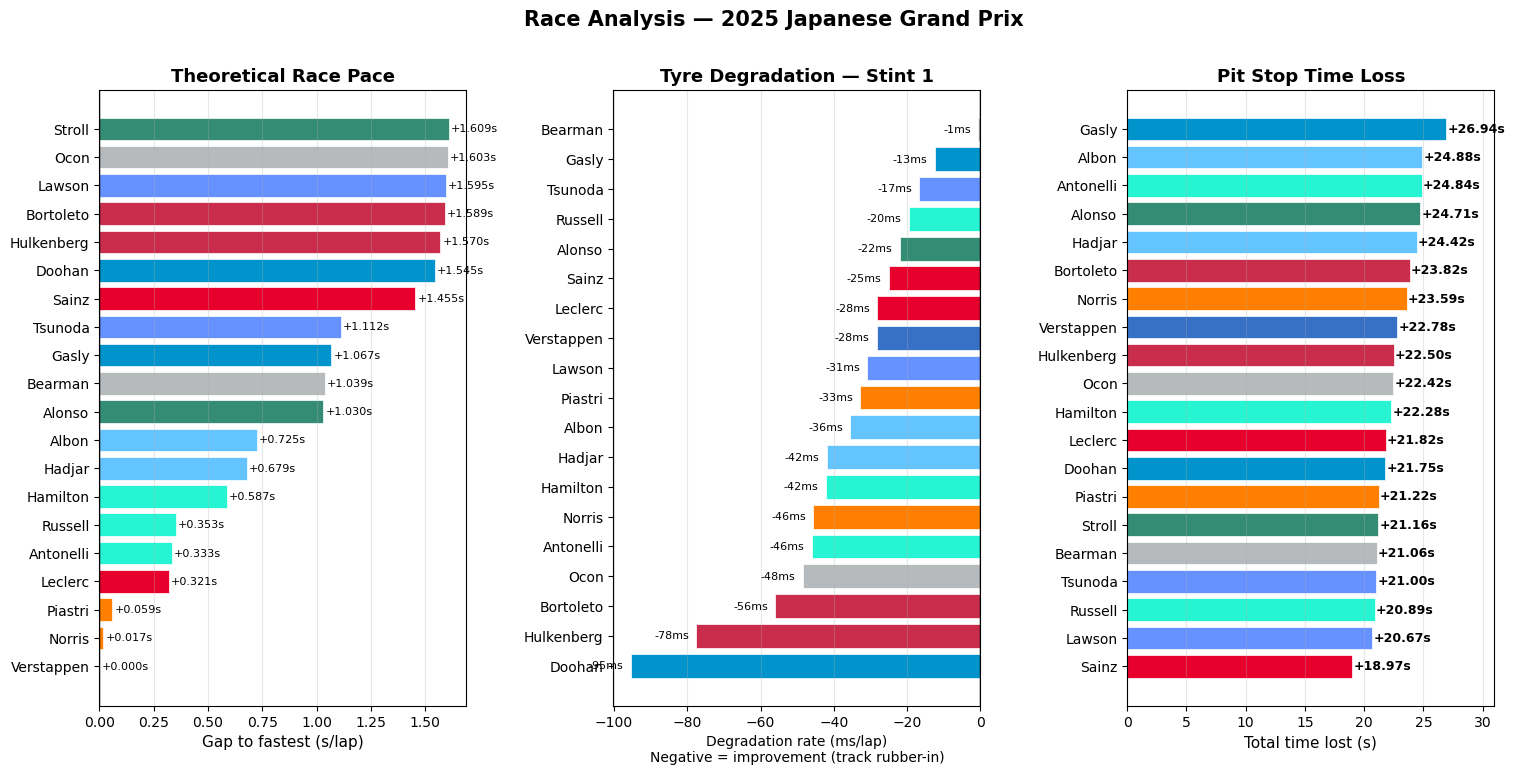

Figure 2 saved!


In [16]:

# ======================================================
# FIGURE 2 — RACE PACE + DEGRADATION + PIT STOP LOSS
# ======================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 8))
fig2.subplots_adjust(wspace=0.4)

# -- Race pace --
ax_pace = axes2[0]
sorted_pace = sorted(pace.items(), key=lambda x: x[1])
names_p = [drivers[d][1] for d, _ in sorted_pace]
colors_p = [drivers[d][0] for d, _ in sorted_pace]
best = sorted_pace[0][1]
gaps = [v - best for _, v in sorted_pace]

bars = ax_pace.barh(names_p, gaps, color=colors_p, edgecolor='white', linewidth=0.5)
ax_pace.set_xlabel('Gap to fastest (s/lap)', fontsize=11)
ax_pace.set_title('Theoretical Race Pace', fontsize=13, fontweight='bold')
ax_pace.axvline(x=0, color='black', linewidth=1)
for bar, gap in zip(bars, gaps):
    ax_pace.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'+{gap:.3f}s', va='center', fontsize=8)
ax_pace.grid(True, alpha=0.3, axis='x')

# -- Dégradation stint 1 (filtré) --
ax_deg = axes2[1]
deg_drivers = [(d, degradation[d].get(1, None)) for d in degradation 
               if degradation[d].get(1) is not None]
# Filtrer les valeurs aberrantes (> 200ms/tour = suspect)
deg_drivers = [(d, v) for d, v in deg_drivers if abs(v) < 200]
deg_drivers.sort(key=lambda x: x[1])
deg_names = [drivers[d][1] for d, _ in deg_drivers]
deg_colors = [drivers[d][0] for d, _ in deg_drivers]
deg_values = [v for _, v in deg_drivers]

bars2 = ax_deg.barh(deg_names, deg_values, color=deg_colors, 
                    edgecolor='white', linewidth=0.5)
ax_deg.set_xlabel('Degradation rate (ms/lap)\nNegative = improvement (track rubber-in)', 
                  fontsize=10)
ax_deg.set_title('Tyre Degradation — Stint 1', fontsize=13, fontweight='bold')
ax_deg.axvline(x=0, color='black', linewidth=1)
for bar, val in zip(bars2, deg_values):
    xpos = bar.get_width() - 2 if val < 0 else bar.get_width() + 2
    ha = 'right' if val < 0 else 'left'
    ax_deg.text(xpos, bar.get_y() + bar.get_height()/2,
               f'{val:.0f}ms', va='center', ha=ha, fontsize=8)
ax_deg.grid(True, alpha=0.3, axis='x')

# -- Pit stop time loss -- total uniquement
ax_pit = axes2[2]
pit_sorted = sorted(pit_losses.items(), key=lambda x: x[1]['loss'])
pit_names = [drivers[d][1] for d, _ in pit_sorted]
pit_colors = [drivers[d][0] for d, _ in pit_sorted]
total_vals = [pit_losses[d]['loss'] for d, _ in pit_sorted]

bars3 = ax_pit.barh(pit_names, total_vals, color=pit_colors, 
                    edgecolor='white', linewidth=0.5)
ax_pit.set_xlabel('Total time lost (s)', fontsize=11)
ax_pit.set_title('Pit Stop Time Loss', fontsize=13, fontweight='bold')
for bar, val in zip(bars3, total_vals):
    ax_pit.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
               f'+{val:.2f}s', va='center', fontsize=9, fontweight='bold')
ax_pit.set_xlim(0, max(total_vals) * 1.15)
ax_pit.grid(True, alpha=0.3, axis='x')

fig2.suptitle('Race Analysis — 2025 Japanese Grand Prix',
              fontsize=15, fontweight='bold')
plt.savefig(r'C:\Users\alexl\Documents\F1-Project\Race_analysis\japan_gp_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved!")